# Live Demo: Grad-CAM (Visual Explanations from Deep Networks)
In this notebook, we will walk through the core concepts of the paper live. We are using a pre-trained **ResNet50** model to investigate exactly what the neural network is looking at when it makes a classification decision.

In [1]:
import cv2
import numpy as np
import requests
import matplotlib.pyplot as plt
import torch
from torchvision.models import resnet50, ResNet50_Weights
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image, preprocess_image

print("Imports successfully loaded!")

Imports successfully loaded!


## Step 1: Load the Model and the Image
First, we load the classic image from the paper (featuring a dog and a cat side-by-side) and prepare it for the neural network. 
Crucially, we also define the **last convolutional layer** (`target_layer`). As discussed, we will keep its spatial feature maps untouched while calculating their gradients during the backward pass.

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/marlon/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:26<00:00, 3.89MB/s]


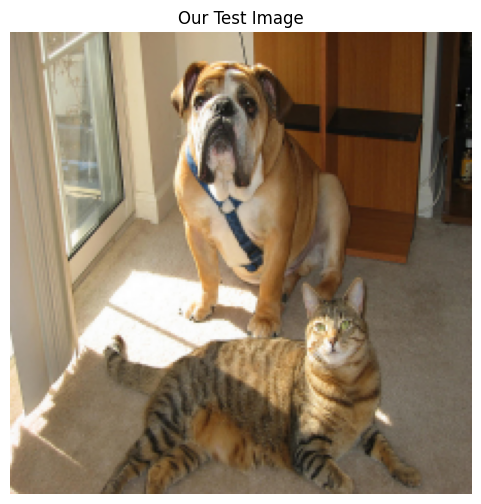

In [2]:
# 1. Load the pre-trained model (ResNet50)
weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights)
model.eval()

# Select the last convolutional layer
target_layers = [model.layer4[-1]]

# 2. Load the image from the internet
url = "https://raw.githubusercontent.com/jacobgil/pytorch-grad-cam/master/examples/both.png"
image_bytes = bytearray(requests.get(url).content)
image_np = np.array(image_bytes, dtype=np.uint8)
rgb_img = cv2.imdecode(image_np, cv2.IMREAD_COLOR)[:, :, ::-1]
rgb_img = np.float32(rgb_img) / 255

# Prepare the image for PyTorch
input_tensor = preprocess_image(rgb_img, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

# Display the original image
plt.figure(figsize=(6, 6))
plt.imshow(rgb_img)
plt.axis('off')
plt.title("Our Test Image")
plt.show()

## Step 2: Demonstrating the "Black Box" Problem
Before applying Grad-CAM, let's look at the raw mathematical output of the model. We run the image through the classifier (Forward Pass) and output the top predictions. Without visual explanations, we only see "naked numbers" and have to blindly trust the model.

In [3]:
# Calculate prediction (Forward Pass)
with torch.no_grad():
    output = model(input_tensor)
    probabilities = torch.nn.functional.softmax(output[0], dim=0)

# Extract and output top 3 classes
top3_prob, top3_catid = torch.topk(probabilities, 3)
categories = weights.meta["categories"]

print("The model detects the following classes in the image:")
for i in range(top3_prob.size(0)):
    print(f"Rank {i+1}: {categories[top3_catid[i]]} (Probability: {top3_prob[i].item()*100:.2f}%)")

The model detects the following classes in the image:
Rank 1: bull mastiff (Probability: 35.00%)
Rank 2: boxer (Probability: 2.42%)
Rank 3: tabby (Probability: 1.71%)


## Step 3: Activate Grad-CAM for the 'Cat'
Now we apply the method from the paper. We calculate the backward pass specifically for the **Tiger Cat class (ImageNet ID: 281)**. Using the chain rule, the system calculates the gradients for all pixels of the feature map in a single step to determine their importance weights ($\alpha_k^c$).

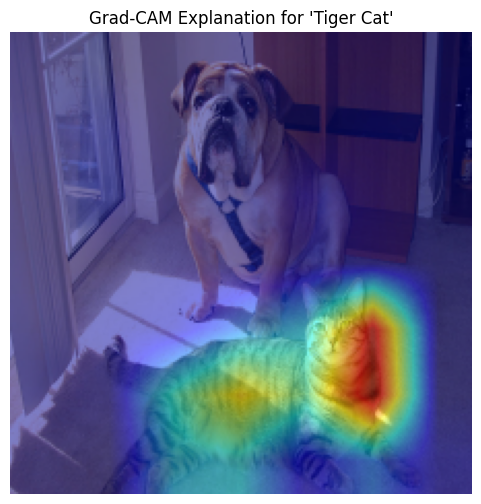

In [4]:
# Initialize Grad-CAM targeting the cat (ID 281)
cam = GradCAM(model=model, target_layers=target_layers)
targets = [ClassifierOutputTarget(281)]

# Calculate the heatmap
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
visualization_cat = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

# Plot the result
plt.figure(figsize=(6, 6))
plt.imshow(visualization_cat)
plt.axis('off')
plt.title("Grad-CAM Explanation for 'Tiger Cat'")
plt.show()

## Step 4: The Live Proof (Class Discrimination)
The paper claims that Grad-CAM is **class-discriminative**. To prove this, we simply tell the algorithm to calculate the gradients for the **Dog (Bullmastiff, ImageNet ID: 243)** instead. The heatmap should immediately jump to the other side of the image, ignoring the cat entirely.

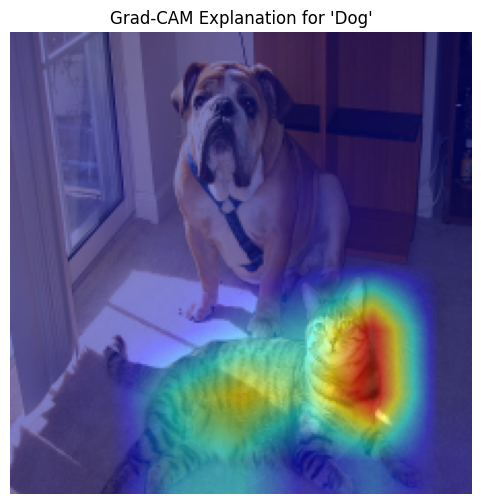

In [ ]:
# Same method, but changing the target to the Dog (ID 243) (Cat ID 281 )
targets_dog = [ClassifierOutputTarget(281)]

# Calculate the new heatmap
grayscale_cam_dog = cam(input_tensor=input_tensor, targets=targets_dog)[0, :]
visualization_dog = show_cam_on_image(rgb_img, grayscale_cam_dog, use_rgb=True)

# Plot the result
plt.figure(figsize=(6, 6))
plt.imshow(visualization_dog)
plt.axis('off')
plt.title("Grad-CAM Explanation for 'Cat'")
plt.show()

## Step 5: Guided Grad-CAM
As we discussed in the theory, standard Grad-CAM is highly class-discriminative but very blurry. **Guided Backpropagation**, on the other hand, extracts high-resolution edges but is *not* class-discriminative (it outlines everything in the image).

Let's fuse them together! By multiplying the sharp edges (Guided Backprop) with our blurry mask (Grad-CAM), we get **Guided Grad-CAM**: high-resolution details that exclusively focus on our target class.

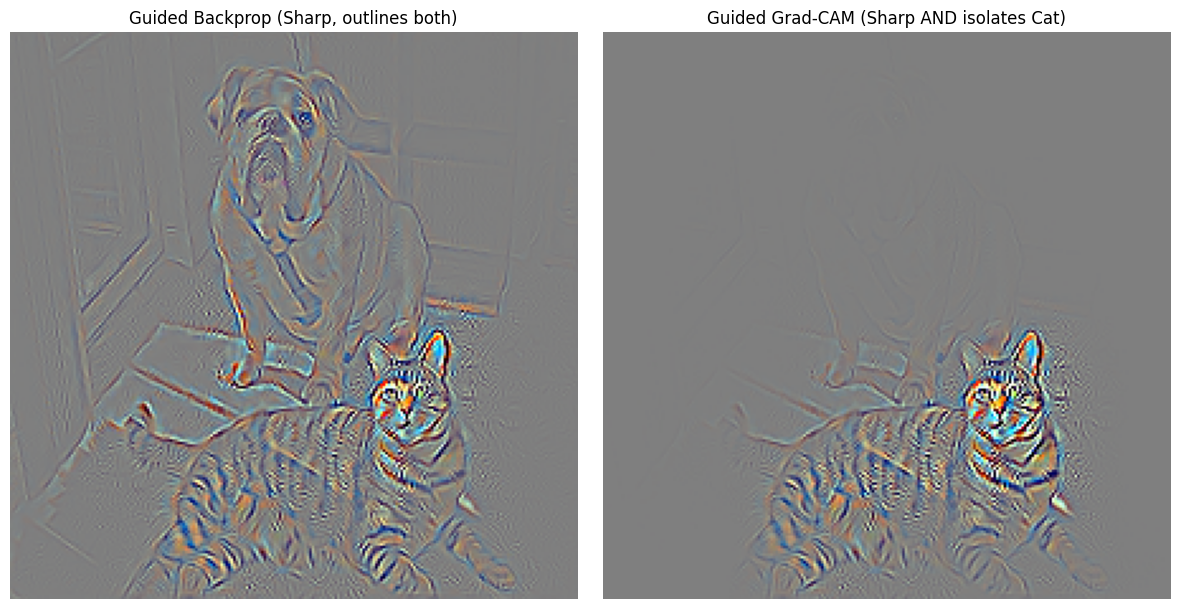

In [12]:
from pytorch_grad_cam import GuidedBackpropReLUModel
from pytorch_grad_cam.utils.image import deprocess_image

# 1. Calculate Guided Backpropagation for the Cat (ID 281)
# We dynamically extract the device from the model (CPU or CUDA) 
# to satisfy the new library requirements.
device = next(model.parameters()).device

# Initialize the model with the explicitly required 'device' parameter
gb_model = GuidedBackpropReLUModel(model=model, device=device)

# We use target_category=281 to specify the class for Guided Backprop
gb = gb_model(input_tensor, target_category=281)

# Deprocess the raw gradients to make them visible as an image
gb_visual = deprocess_image(gb)

# 2. Create Guided Grad-CAM
# We multiply the sharp edges with our blurry cat mask from Step 3
# First, we need to make our 1D mask 3D (RGB) so we can multiply it
cam_mask = cv2.merge([grayscale_cam, grayscale_cam, grayscale_cam])

# Element-wise multiplication
guided_grad_cam = deprocess_image(cam_mask * gb)

# 3. Plot the dramatic comparison
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].imshow(gb_visual)
axs[0].set_title("Guided Backprop (Sharp, outlines both)")
axs[0].axis('off')

axs[1].imshow(guided_grad_cam)
axs[1].set_title("Guided Grad-CAM (Sharp AND isolates Cat)")
axs[1].axis('off')

plt.tight_layout()
plt.show()